# SpaceX S-1 — How do you get to \$1.77 TRILLION?

It's no longer hypothetical. On **June 3, 2026** SpaceX priced its IPO at **\$135/share — a \$1.77T
valuation**, selling 555.6M shares for a **~\$75B raise** (Nasdaq:SPCX, the largest IPO in history; the
7th-most-valuable US company, above Tesla). Our own DCF + football field (`notebooks/valuation.ipynb`) value
the equity at **~\$150–240B**. So the market is paying **roughly 8–11× our number**, and the question is no
longer "is the hype crazy?" but **"what is the actual bull thesis, and where does it break?"**

This notebook reverse-engineers \$1.77T. The plan: isolate how big the bet is and on what (it starts as an AI
bet so large it strains belief), then build the bull's *best* defense — a bigger Starlink, a bigger Space, a
compute-scarcity landlord story, and the orbital-datacenter "unlock" that supposedly ties it together — and
test each. The math lives in `analysis/trillion.py`; external marks are in `csv/ai_labs.csv` /
`csv/market_marks.csv` (live web search, Jun-2026).

## Setup

Load the engine and define one dollar-formatting helper. Net debt and the share count are the same S-1 inputs
the DCF uses.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from analysis import charts, dcf, valuation as val
import analysis.trillion as tr

charts.apply_style()
SEG  = charts.SEGMENT_COLORS        # repo-wide segment colors (Connectivity / Space / AI)
RED  = "#c0392b"                    # "what you must ASSUME" (required / IPO)
GREY = "#5a6b8c"                    # real AI labs / neutral

def usd(x):
    """$-label for matplotlib. The leading backslash escapes mathtext, otherwise a bare
    '$' starts a LaTeX span. Small amounts (<$10B) keep one decimal."""
    digits = 1 if abs(x) < 10 else 0
    return rf"\${x:,.{digits}f}B"

IPO    = tr.IPO_PRICE_B             # $1,770B
SHARES = val.shares_m()
NET_DEBT = val.net_debt_m() / 1000  # $B
A = dcf.default_assumptions()
print(f"IPO valuation: ${IPO:,.0f}B  (${tr.IPO_SHARE_PRICE:.0f}/share)")
print(f"Pro-forma shares: {SHARES:,.0f}M    net debt: ${NET_DEBT:.0f}B")

IPO valuation: $1,770B  ($135/share)
Pro-forma shares: 12,520M    net debt: $14B


## The gap: the IPO is ~8–11× our cash-flow value

Three numbers, in equity terms. Our DCF (which already runs a generous bull) and the established private mark
sit far below the IPO. On a per-share basis the gap is just as stark: our work says **~\$12 (base) to \$18
(bull)** per share; the IPO priced at **\$135**.

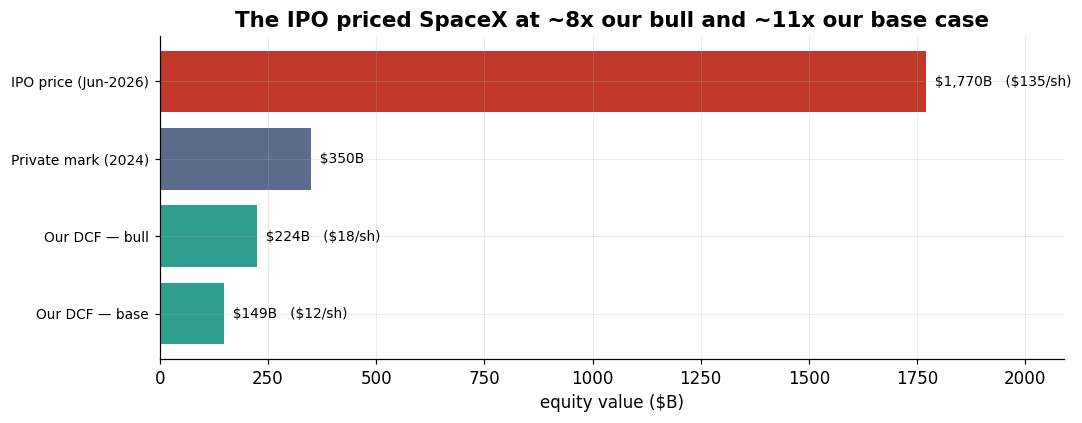

In [2]:
dr = val.dcf_range(A)                       # bear-floor / base / bull equity ($M)
ps = lambda equity_b: equity_b * 1000 / SHARES   # $B equity -> $/share (pre-IPO count)

points = [
    ("Our DCF — base",        dr["base"] / 1000, SEG["Connectivity"]),
    ("Our DCF — bull",        dr["bull"] / 1000, SEG["Connectivity"]),
    ("Private mark (2024)",   val.private_mark_anchor_b(), GREY),
    ("IPO price (Jun-2026)",  IPO, RED),
]
fig, ax = plt.subplots(figsize=(10, 4))
for i, (label, value, color) in enumerate(points):
    ax.barh(i, value, color=color)
    tag = rf"  {usd(value)}   (\${ps(value):.0f}/sh)" if label.startswith("Our") else f"  {usd(value)}"
    if label.startswith("IPO"):
        tag = rf"  {usd(value)}   (\${tr.IPO_SHARE_PRICE:.0f}/sh)"
    ax.text(value, i, tag, va="center", fontsize=9)
ax.set_yticks(range(len(points))); ax.set_yticklabels([p[0] for p in points], fontsize=9)
ax.set_xlim(0, IPO * 1.18)
ax.set_xlabel(r"equity value (\$B)")
ax.set_title("The IPO priced SpaceX at ~8x our bull and ~11x our base case", fontweight="bold")
charts.finish(fig); charts.save(fig, "trillion_gap"); plt.show()

## Step 1 — If AI carries it alone, it must be worth ~\$1.55T

Same bridge as before, in **enterprise-value space**: value Connectivity and Space at our own **Bull**, and
the residual to reach \$1.77T is what the AI segment must be worth. The answer is brutal: **~\$1.55T** — *more
than our entire valuation of the company, several times over*, and (as the next chart shows) nearly OpenAI and
Anthropic **combined**.

Connectivity (Bull): +$208B
Space (Bull):        +$22B
AI (required):       +$1,555B
net debt:            -$14B
= IPO equity:         $1,770B


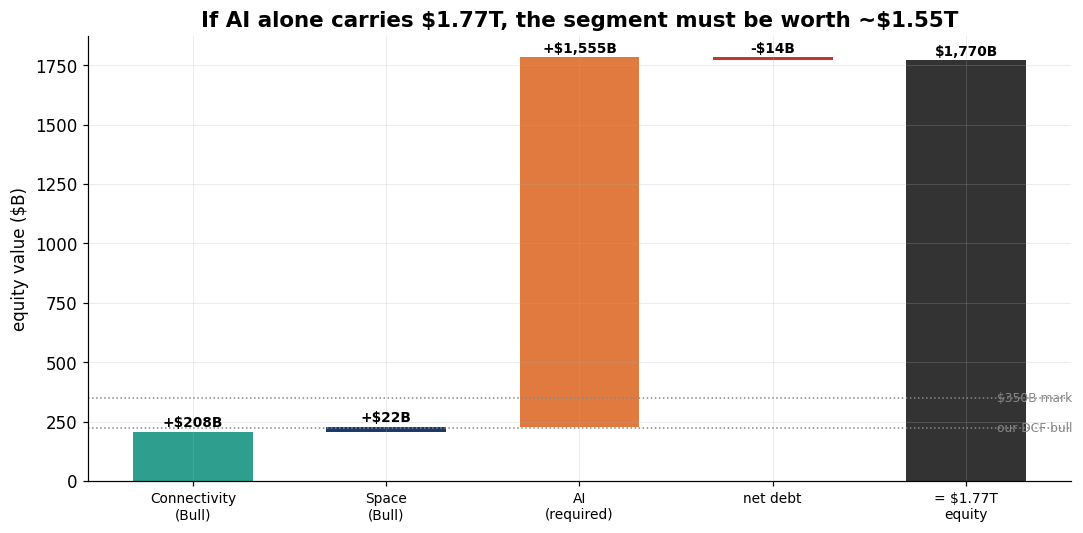

In [3]:
b      = tr.bridge(IPO, conn_scn="Bull", space_scn="Bull")
conn   = b["components_b"]["Connectivity"]
space  = b["components_b"]["Space"]
ai_req = b["ai_required_ev_b"]            # AI-only residual to reach $1.77T
print(f"Connectivity (Bull): +{usd(conn).replace(chr(92),'')}")
print(f"Space (Bull):        +{usd(space).replace(chr(92),'')}")
print(f"AI (required):       +{usd(ai_req).replace(chr(92),'')}")
print(f"net debt:            -{usd(NET_DEBT).replace(chr(92),'')}")
print(f"= IPO equity:         {usd(conn+space+ai_req-NET_DEBT).replace(chr(92),'')}")

labels = ["Connectivity\n(Bull)", "Space\n(Bull)", "AI\n(required)", "net debt", "= $1.77T\nequity"]
steps  = [conn, space, ai_req, -NET_DEBT]
colors = [SEG["Connectivity"], SEG["Space"], SEG["AI"], RED]

fig, ax = plt.subplots(figsize=(10, 5))
running = 0.0
for i, (value, color) in enumerate(zip(steps, colors)):
    bottom = running if value >= 0 else running + value
    ax.bar(i, abs(value), bottom=bottom, color=color, width=0.62)
    ax.text(i, bottom + abs(value) + 20, ("+" if value >= 0 else "-") + usd(abs(value)),
            ha="center", fontweight="bold", fontsize=9)
    running += value
ax.bar(4, running, color="#333", width=0.62)
ax.text(4, running + 20, usd(running), ha="center", fontweight="bold", fontsize=9)
for level, text in [(dr["high"]/1000, "our DCF bull"), (val.private_mark_anchor_b(), r"\$350B mark")]:
    ax.axhline(level, ls=":", lw=1, color="#888")
    ax.text(4.55, level, text, fontsize=8, color="#888", va="center", ha="right")
ax.set_xticks(range(5)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel(r"equity value (\$B)")
ax.set_title(r"If AI alone carries \$1.77T, the segment must be worth ~\$1.55T", fontweight="bold")
charts.finish(fig); charts.save(fig, "trillion_bridge"); plt.show()

## Step 2 — \$1.55T of AI is nearly *OpenAI and Anthropic combined*

Put that residual next to the real price tags (June-2026, `csv/ai_labs.csv`). The required AI value isn't "a
rich multiple" — it is **the entire frontier-lab industry**. SpaceX's AI segment earns **~\$3.2B** of revenue
today; OpenAI and Anthropic earn \$24B and \$47B. The bridge asks you to value the smallest-revenue lab as if
it were both of the leaders at once.

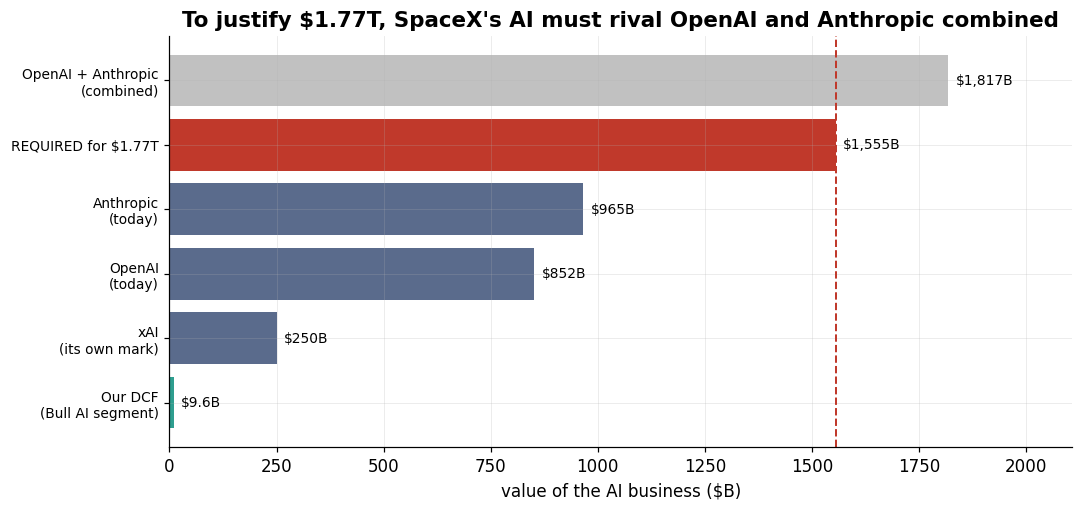

In [4]:
labs = tr.load_ai_labs().set_index("entity")
ai_dcf_bull = dcf.value_scenario("Bull", A)["ev"]["AI"] / 1000
combined = float(labs.loc["OpenAI", "valuation_usd_b"]) + float(labs.loc["Anthropic", "valuation_usd_b"])

items = [
    ("Our DCF\n(Bull AI segment)",   ai_dcf_bull,                                "ours"),
    ("xAI\n(its own mark)",          float(labs.loc["xAI", "valuation_usd_b"]),       "lab"),
    ("OpenAI\n(today)",              float(labs.loc["OpenAI", "valuation_usd_b"]),    "lab"),
    ("Anthropic\n(today)",           float(labs.loc["Anthropic", "valuation_usd_b"]), "lab"),
    ("REQUIRED for $1.77T",          ai_req,                                     "required"),
    ("OpenAI + Anthropic\n(combined)", combined,                                 "ref"),
]
items.sort(key=lambda r: r[1])
color = {"ours": SEG["Connectivity"], "lab": GREY, "required": RED, "ref": "#999"}

fig, ax = plt.subplots(figsize=(10, 4.8))
for i, (label, value, cat) in enumerate(items):
    ax.barh(i, value, color=color[cat], alpha=0.6 if cat == "ref" else 1.0)
    ax.text(value + 18, i, usd(value), va="center", fontsize=9)
ax.axvline(ai_req, ls="--", lw=1.3, color=RED)
ax.set_yticks(range(len(items))); ax.set_yticklabels([r[0] for r in items], fontsize=9)
ax.set_xlim(0, combined * 1.16)
ax.set_xlabel(r"value of the AI business (\$B)")
ax.set_title("To justify $1.77T, SpaceX's AI must rival OpenAI and Anthropic combined", fontweight="bold")
charts.finish(fig); charts.save(fig, "trillion_ai_vs_labs"); plt.show()

## Step 3 — The bull's real move: don't put it all on AI, stack every segment

Nobody actually argues "\$1.55T of AI." The bull thesis spreads the load — it gives **every** segment its
category-monopoly best case at once:

- **Connectivity becomes the world's telecom.** Direct-to-cell + broadband + enterprise/gov/maritime/aviation
  taking it from ~\$11B revenue today to ~\$100B, at the 6–10× sales the comps allow → **~\$700B** (vs our
  Bull \$208B). Starlink is the cash engine that funds everything else.
- **Space becomes the world's launch + logistics layer.** Commercial + national-security launch, Starship
  cargo, point-to-point Earth transport, lunar/Mars, in-space manufacturing → ~\$55B revenue at a launch-
  monopoly multiple → **~\$385B** (vs our Bull \$22B).

Stack those and the AI residual drops from \$1.55T to **~\$700B**. That sounds like relief — until you notice
**\$700B is still an entire OpenAI**. So the honest read of \$1.77T isn't one heroic assumption; it's **three
simultaneous global monopolies** — in connectivity, in launch, *and* in AI.

Connectivity mega-bull: $700B  ($100B rev x 7)
Space mega-bull:        $385B  ($55B rev x 7)
=> AI still required:   $699B  (~a whole OpenAI)


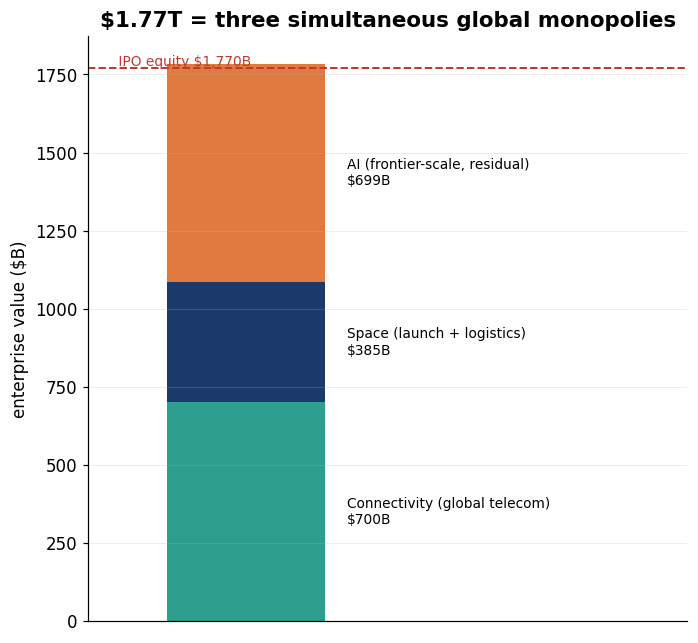

In [5]:
# Mega-bull each non-AI segment, then AI is the residual to reach $1.77T.
conn_mega  = tr.connectivity_megabull_b(revenue_b=100, ev_rev=7)   # $700B
space_mega = tr.space_megabull_b(revenue_b=55, ev_rev=7)           # $385B
ms = tr.maximal_sotp(IPO, conn_b=conn_mega, space_b=space_mega)
ai_mega = ms["ai_resid"]
print(f"Connectivity mega-bull: {usd(conn_mega).replace(chr(92),'')}  ($100B rev x 7)")
print(f"Space mega-bull:        {usd(space_mega).replace(chr(92),'')}  ($55B rev x 7)")
print(f"=> AI still required:   {usd(ai_mega).replace(chr(92),'')}  (~a whole OpenAI)")

# One stacked column: the three segment best-cases sum to the IPO enterprise value.
segs   = [("Connectivity (global telecom)", conn_mega, SEG["Connectivity"]),
          ("Space (launch + logistics)",    space_mega, SEG["Space"]),
          ("AI (frontier-scale, residual)", ai_mega,   SEG["AI"])]
fig, ax = plt.subplots(figsize=(6.5, 6))
bottom = 0.0
for label, value, color in segs:
    ax.bar(0, value, bottom=bottom, color=color, width=0.5)
    ax.text(0.32, bottom + value/2, f"{label}\n{usd(value)}", va="center", fontsize=9)
    bottom += value
ax.axhline(IPO, ls="--", color=RED, lw=1.3)
ax.text(-0.42, IPO, rf" IPO equity {usd(IPO)}", color=RED, fontsize=9, va="bottom")
ax.set_xlim(-0.5, 1.4); ax.set_xticks([])
ax.set_ylabel(r"enterprise value (\$B)")
ax.set_title("$1.77T = three simultaneous global monopolies", fontweight="bold")
charts.finish(fig); charts.save(fig, "trillion_sotp"); plt.show()

## Step 4 — The compute-landlord bet: what if GPU prices go *up*?

How could the AI segment alone be worth \$700B–\$1.5T on cash flows? One lever dominates: the **price SpaceX
can charge per GPU-hour**. Our base case assumes ~\$2/GPU-hr and *falling* (the historical pattern — compute
gets cheaper). The bull bets the opposite: that AI demand outruns supply, compute stays **scarce**, and SpaceX
— with capital, power access, and a fleet — becomes the **landlord** renting compute to everyone else at fat,
rising margins.

The chart holds the fleet at a fixed 10 GW and sweeps the lease price. The leverage is enormous: at today's
~\$2/GPU-hr the segment is barely worth anything; at **~\$6/GPU-hr it clears \$1.1T on its own**. So the entire
AI case rests on a single contrarian belief — that the price of compute *rises* instead of falling.

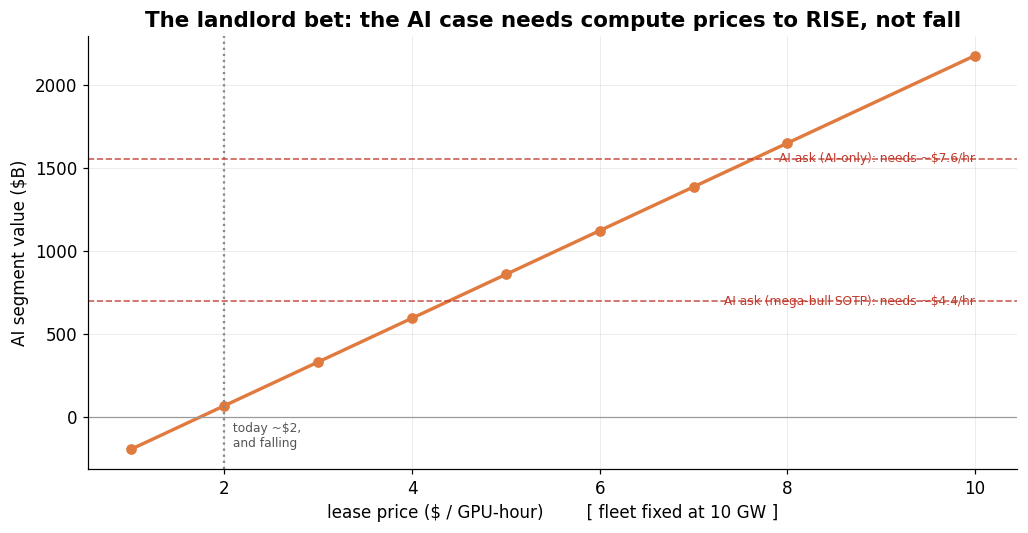

In [6]:
prices = np.array([1, 2, 3, 4, 5, 6, 7, 8, 10])
evs = np.array([tr.super_bull_ai_ev(tr.AISuperBull(gw=10, util=0.88, price=float(p)))["ev"] / 1000
                for p in prices])

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(prices, evs, "-o", color=SEG["AI"], lw=2.2)
ax.axhline(0, color="#999", lw=0.8)
# mark today's ~$2 and the levels needed to clear the AI ask
ax.axvline(2, ls=":", color="#888"); ax.text(2.05, evs.min(), " today ~$2,\n and falling", fontsize=8, color="#555", va="bottom")
for level, name in [(ai_mega, "AI ask (mega-bull SOTP)"), (ai_req, "AI ask (AI-only)")]:
    ax.axhline(level, ls="--", lw=1.1, color=RED, alpha=0.8)
    xcross = float(np.interp(level, evs, prices))
    ax.text(10, level, rf" {name}: needs ~\${xcross:.1f}/hr", color=RED, fontsize=8, va="center", ha="right")
ax.set_xlabel(r"lease price (\$ / GPU-hour)        [ fleet fixed at 10 GW ]")
ax.set_ylabel(r"AI segment value (\$B)")
ax.set_title("The landlord bet: the AI case needs compute prices to RISE, not fall", fontweight="bold")
charts.finish(fig); charts.save(fig, "trillion_compute_price"); plt.show()

## Step 5 — Either way, you have to *build* it: ~15 GW = a couple dozen reactors

High prices still require a fleet big enough to matter. Cranking the DCF's AI dials, even the **\$700B**
"minimum" AI (after mega-bulling Starlink and Space) needs roughly **~15 GW** of compute — which, decoded into
physical reality, is millions of GPUs, hundreds of billions of build capex, and **~20 nuclear reactors' worth
of continuous power**. That power wall is the setup for the bull's most futuristic claim, next.

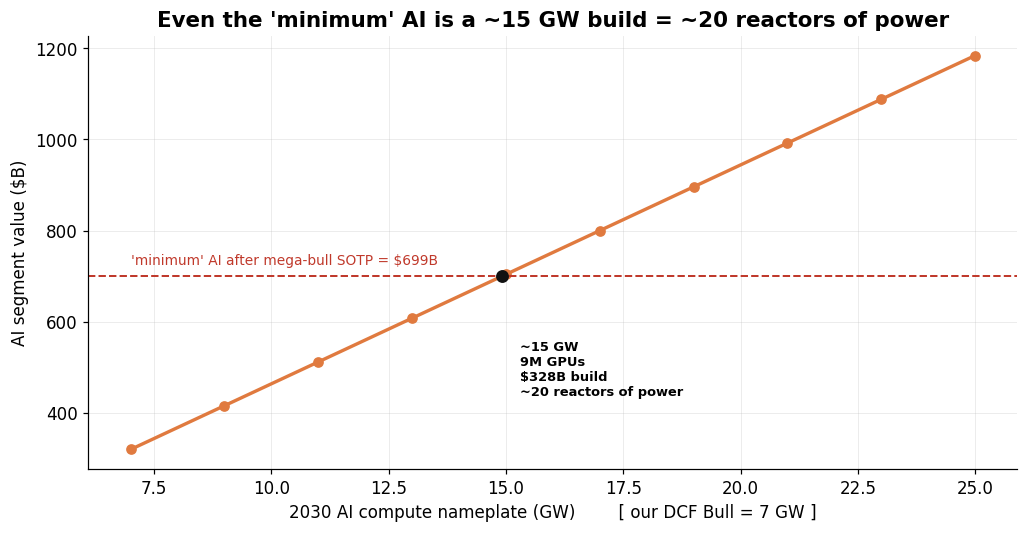

In [7]:
gws = np.array([7, 9, 11, 13, 15, 17, 19, 21, 23, 25])
evs = np.array([tr.super_bull_ai_ev(tr.AISuperBull(gw=g, util=0.88, price=3.5))["ev"] / 1000 for g in gws])
cross_gw = float(np.interp(ai_mega, evs, gws))     # GW to reach the $700B "minimum" AI
dec = tr.infra_decode(cross_gw)

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(gws, evs, "-o", color=SEG["AI"], lw=2.2)
ax.axhline(ai_mega, ls="--", lw=1.3, color=RED)
ax.text(7, ai_mega + 25, rf"'minimum' AI after mega-bull SOTP = {usd(ai_mega)}", color=RED, fontsize=9)
ax.scatter([cross_gw], [ai_mega], color="#111", s=55, zorder=5)
ax.annotate(f"~{cross_gw:.0f} GW\n{dec['gpus_m']:.0f}M GPUs\n{usd(dec['build_capex_b'])} build\n"
            f"~{dec['reactor_equiv']:.0f} reactors of power",
            (cross_gw, ai_mega), xytext=(12, -78), textcoords="offset points",
            fontsize=8.5, fontweight="bold")
ax.set_xlabel("2030 AI compute nameplate (GW)        [ our DCF Bull = 7 GW ]")
ax.set_ylabel(r"AI segment value (\$B)")
ax.set_title("Even the 'minimum' AI is a ~15 GW build = ~20 reactors of power", fontweight="bold")
charts.finish(fig); charts.save(fig, "trillion_cash_path"); plt.show()

## Step 6 — The "unlock": orbital datacenters — and why the physics says no

Here's the narrative that supposedly makes SpaceX *uniquely* worth \$1.77T: Earth can't build 20 reactors of
datacenter power fast enough (grid, permitting, NIMBY), so **put the compute in space** — 24/7 solar, no grid,
no land — and SpaceX, with the launch monopoly, is the only company that can deploy it. It's the vertical-
integration story that ties Space + Connectivity-style ops + AI into one moat, and the S-1 name-checks it.

It does not survive thermodynamics. Per the [GPUs-in-Space analysis](https://goodatinvesting.com/website/gpus-in-space/),
a space datacenter costs **~\$210B/GW vs ~\$50B/GW on the ground — a 4.2× penalty** — because in vacuum you can
only shed heat by **radiation**: ~a **tennis court of radiator (≈487 kg) per 8 GPUs**, all of it launched at
**\$2,500–5,500/kg**. GPUs are only ~11% of the orbital bill; the rest is the "space premium." So orbital
compute doesn't make the AI build cheaper — it makes it **~4× more expensive**. It "solves" the power wall by
torching the economics. As the author puts it: if you can't name the specific breakthrough doing the work,
it's just *the word "space" slapped onto a popular industry.*

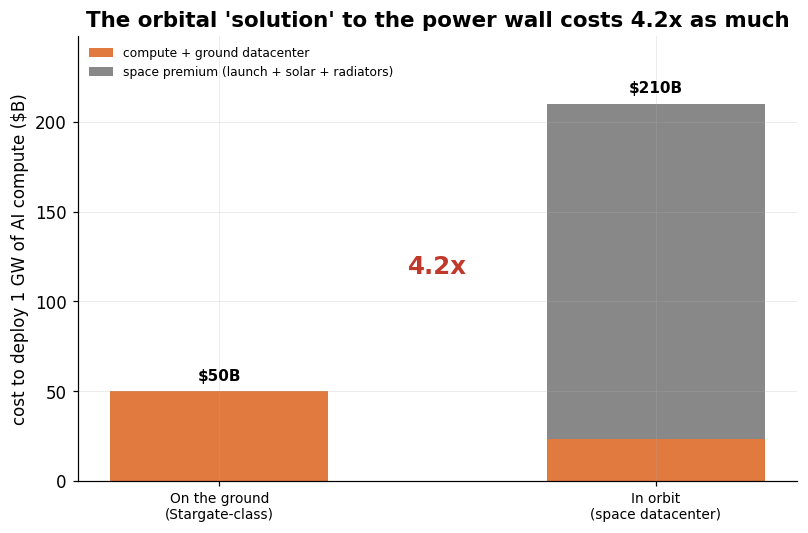

Radiator per 8 GPUs: 243 m2 (~a tennis court), 487 kg
Launch: $2,500/kg (LEO) to $5,500/kg (MEO)


In [8]:
o = tr.ORBITAL_DC
terr, orb = o["terrestrial_cost_per_gw_b"], o["orbital_cost_per_gw_b"]

fig, ax = plt.subplots(figsize=(7.5, 5))
# terrestrial: one bar; orbital: split into GPUs vs the launch+solar+radiator "space premium"
ax.bar(0, terr, width=0.5, color=SEG["AI"], label="compute + ground datacenter")
gpu = orb * o["gpu_cost_share"]
ax.bar(1, gpu, width=0.5, color=SEG["AI"])
ax.bar(1, orb - gpu, bottom=gpu, width=0.5, color="#888",
       label="space premium (launch + solar + radiators)")
ax.text(0, terr + 6, usd(terr), ha="center", fontweight="bold", fontsize=10)
ax.text(1, orb + 6, usd(orb), ha="center", fontweight="bold", fontsize=10)
ax.annotate(f"{o['premium_x']:.1f}x", (0.5, orb * 0.55), ha="center", fontsize=16,
            fontweight="bold", color=RED)
ax.set_xticks([0, 1]); ax.set_xticklabels(["On the ground\n(Stargate-class)", "In orbit\n(space datacenter)"], fontsize=9)
ax.set_ylabel(r"cost to deploy 1 GW of AI compute (\$B)")
ax.set_ylim(0, orb * 1.18)
ax.set_title("The orbital 'solution' to the power wall costs 4.2x as much", fontweight="bold")
ax.legend(fontsize=8, frameon=False, loc="upper left")
charts.finish(fig); charts.save(fig, "trillion_orbital"); plt.show()
print(f"Radiator per 8 GPUs: {o['radiator_m2_per_8gpu']:.0f} m2 (~a tennis court), {o['radiator_kg_per_8gpu']:.0f} kg")
print(f"Launch: ${o['launch_usd_per_kg_leo']:,}/kg (LEO) to ${o['launch_usd_per_kg_meo']:,}/kg (MEO)")

## Step 7 — As an AGI lottery, \$1.77T pays the steepest odds of anyone

Strip it back to the bet underneath. Treat each lab as a ticket on a common **\$10T** transformative-AI prize,
credit a no-AGI business first (~12× revenue), and read the residual as an implied probability. At \$1.77T the
AI-only residual implies xAI has a **~16%** chance of winning AGI — roughly **triple** OpenAI's or Anthropic's
implied odds, on a fraction of their revenue. (Even the gentler mega-bull-SOTP residual of \$700B implies
~7%, still at the top of the table.) You are paying the highest AGI odds in the market for the lab with the
least to show for it.

                      entity  valuation_b  runrate_b implied P(win AGI)
                         xAI    250.00000      0.500               2.4%
                   Anthropic    965.00000     47.000               4.0%
                      OpenAI    852.00000     24.000               5.6%
SpaceX·AI (implied @ $1.77T)   1555.19164      3.201              15.2%


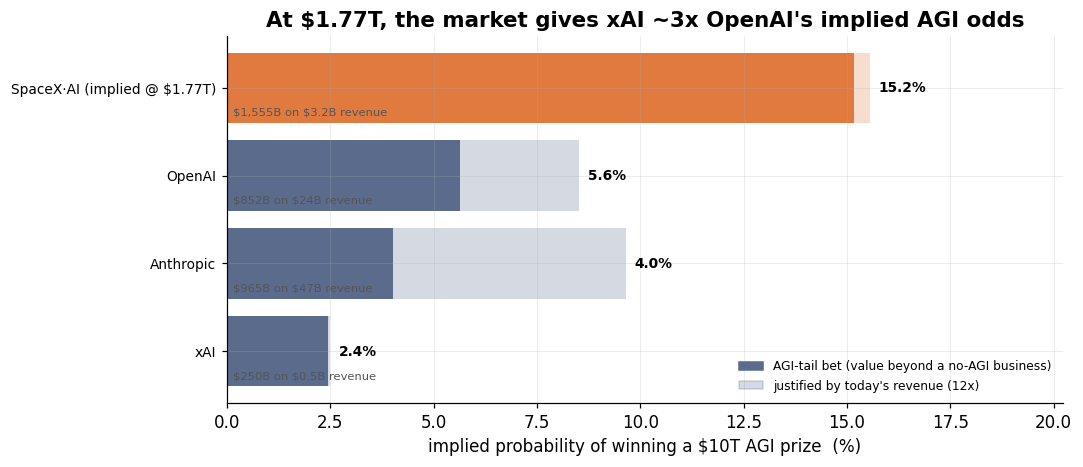

In [9]:
lott = tr.agi_lottery_table(prize_b=10_000.0, floor_mult=12.0, target_equity_b=IPO).sort_values("p_floor")
print(lott[["entity", "valuation_b", "runrate_b", "p_floor"]]
      .rename(columns={"p_floor": "implied P(win AGI)"})
      .to_string(index=False, formatters={"implied P(win AGI)": lambda p: f"{p:.1%}"}))

fig, ax = plt.subplots(figsize=(10, 4.4))
for i, (_, row) in enumerate(lott.iterrows()):
    c = SEG["AI"] if row.kind == "spacex" else GREY
    ax.barh(i, row.p_floor * 100, color=c)
    ax.barh(i, (row.p_pure - row.p_floor) * 100, left=row.p_floor * 100, color=c, alpha=0.25)
    ax.text(row.p_pure * 100 + 0.2, i, f"{row.p_floor:.1%}", va="center", fontsize=9, fontweight="bold")
    ax.text(0.15, i - 0.28, f"{usd(row.valuation_b)} on {usd(row.runrate_b)} revenue",
            va="center", fontsize=7.5, color="#555")
ax.set_yticks(range(len(lott))); ax.set_yticklabels(lott.entity, fontsize=9)
ax.set_xlim(0, lott.p_pure.max() * 100 * 1.3)
ax.set_xlabel(r"implied probability of winning a \$10T AGI prize  (%)")
ax.set_title("At $1.77T, the market gives xAI ~3x OpenAI's implied AGI odds", fontweight="bold")
ax.legend(handles=[Patch(color=GREY, label="AGI-tail bet (value beyond a no-AGI business)"),
                   Patch(color=GREY, alpha=0.25, label="justified by today's revenue (12x)")],
          loc="lower right", fontsize=8, frameon=False)
charts.finish(fig); charts.save(fig, "trillion_agi_lottery"); plt.show()

## Verdict — \$1.77T is a stack of monopolies wrapped around an AGI bet

Every lens lands in the same place. \$1.77T is **not** a valuation of a rockets-and-broadband company; it is a
*portfolio of simultaneous best-cases*, and you have to believe most of them at once:

| Lens | What \$1.77T makes you believe |
|---|---|
| **Per share** | \$135 vs our \$12 (base) / \$18 (bull) — an **8–11×** premium to discounted cash flow. |
| **AI-only bridge** | The AI segment is worth ~\$1.55T — *nearly OpenAI + Anthropic combined*, on ~\$3.2B of revenue. |
| **Stack the segments** | Even gifting Starlink (~\$700B, global telecom) and Space (~\$385B, launch+logistics monopoly) their best cases, AI **still** must be worth ~\$700B — a whole OpenAI. Three monopolies at once. |
| **Compute landlord** | The AI cash flows only work if GPU lease prices **rise** to ~\$4–7/hr (vs ~\$2 and falling) and SpaceX rents at fat margins. |
| **The build** | ~15+ GW of compute = millions of GPUs, hundreds of \$B of capex, **~20 reactors** of power. |
| **Orbital "unlock"** | The story that only SpaceX can dodge the power wall by going to space — except orbital compute costs **~4.2× more** (radiators, launch). The moat is a cost penalty in a futurist costume. |
| **AGI lottery** | xAI implied at a **~16%** chance of winning AGI — ~3× OpenAI's odds, on a fraction of the revenue. |

So **can** you justify \$1.77T? Only by stacking it: a Bull-case Starlink that becomes the planet's telecom, a
Space business that becomes the planet's logistics layer, an AI segment valued like the entire frontier-lab
industry, compute prices that defy gravity, and — to make the AI piece *uniquely* SpaceX's — an orbital-
datacenter moat that the physics turns into a 4.2× cost penalty. Each is a thing *someone* believes. Believing
**all of them simultaneously**, and calling the product a "valuation," is the part worth being skeptical of.
The cash flows say ~\$150–240B; the market is paying for the option that every one of these bets pays off.

> *Provenance:* AI-lab marks (`csv/ai_labs.csv`) and the \$1.77T IPO price (`csv/market_marks.csv`) are
> external, live web search Jun-2026. Orbital-datacenter figures are from
> [goodatinvesting.com/website/gpus-in-space](https://goodatinvesting.com/website/gpus-in-space/). The bridge
> is a residual on our own DCF, so it's robust to the marks' exact level; the segment mega-bull sizes are
> deliberately aggressive assumptions, labeled as such.